<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/GAN_with_text_cleaned_merged_memotion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [2]:

!kaggle datasets download -d williamscott701/memotion-dataset-7k

! unzip "memotion-dataset-7k.zip"


Streaming output truncated to the last 5000 lines.
  inflating: memotion_dataset_7k/images/image_2799.png  
  inflating: memotion_dataset_7k/images/image_28.jpg  
  inflating: memotion_dataset_7k/images/image_280.jpg  
  inflating: memotion_dataset_7k/images/image_2800.png  
  inflating: memotion_dataset_7k/images/image_2801.png  
  inflating: memotion_dataset_7k/images/image_2802.png  
  inflating: memotion_dataset_7k/images/image_2803.png  
  inflating: memotion_dataset_7k/images/image_2804.png  
  inflating: memotion_dataset_7k/images/image_2805.jpg  
  inflating: memotion_dataset_7k/images/image_2806.jpg  
  inflating: memotion_dataset_7k/images/image_2807.jpg  
  inflating: memotion_dataset_7k/images/image_2808.jpg  
  inflating: memotion_dataset_7k/images/image_2809.png  
  inflating: memotion_dataset_7k/images/image_281.png  
  inflating: memotion_dataset_7k/images/image_2810.jpg  
  inflating: memotion_dataset_7k/images/image_2811.jpg  
  inflating: memotion_dataset_7k/images/i

In [3]:
import os
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# Example: Load labels and merge them
labels_df = pd.read_csv('/content/memotion_dataset_7k/labels.csv')  # adjust filename if needed

def merge_labels(row):
    if row['overall_sentiment'] in ['negative', 'very_negative']:  # adjust as needed
        return 'negative'
    if row['overall_sentiment'] in ['positive', 'very_positive', ]:  # adjust as needed
        return 'positive'
    else:
        return 'neutral'

labels_df['merged_label'] = labels_df.apply(merge_labels, axis=1)

# Optional: Save for reference
labels_df[['image_name', 'merged_label']].to_csv('labels_merged.csv', index=False)

In [4]:
labels_df.head()

,Unnamed: 0,image_name,text_ocr,text_corrected,humour,sarcasm,offensive,motivational,overall_sentiment,merged_label
0,0,image_1.jpg,LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...,LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...,hilarious,general,not_offensive,not_motivational,very_positive,positive
1,1,image_2.jpeg,The best of #10 YearChallenge! Completed in le...,The best of #10 YearChallenge! Completed in le...,not_funny,general,not_offensive,motivational,very_positive,positive
2,2,image_3.JPG,Sam Thorne @Strippin ( Follow Follow Saw every...,Sam Thorne @Strippin ( Follow Follow Saw every...,very_funny,not_sarcastic,not_offensive,not_motivational,positive,positive
3,3,image_4.png,10 Year Challenge - Sweet Dee Edition,10 Year Challenge - Sweet Dee Edition,very_funny,twisted_meaning,very_offensive,motivational,positive,positive
4,4,image_5.png,10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...,10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...,hilarious,very_twisted,very_offensive,not_motivational,neutral,neutral


In [6]:
import os
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# Example: Load labels and merge them
labels_df = pd.read_csv('/content/memotion_dataset_7k/labels.csv')  # adjust filename if needed

def merge_labels(row):
    if row['overall_sentiment'] in ['negative', 'very_negative']:  # adjust as needed
        return 'negative'
    if row['overall_sentiment'] in ['positive', 'very_positive', ]:  # adjust as needed
        return 'positive'
    else:
        return 'neutral'

labels_df['merged_label'] = labels_df.apply(merge_labels, axis=1)

# Optional: Save for reference
labels_df[['image_name', 'merged_label']].to_csv('labels_merged.csv', index=False)


In [5]:
# Reinstall easyocr in this environment
!pip install easyocr --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# Re-import required libraries after environment reset
import os
import cv2
import pandas as pd
import numpy as np
import easyocr
from tqdm import tqdm

# Define paths again
input_dir = "/content/memotion_dataset_7k/images"  # Folder containing original images
output_dir = "/content/images_impainted"  # Output folder for inpainted images
csv_path = "/content/labels_merged.csv"  # CSV file with image names and labels
updated_csv_path = "/content/meme_labels_inpainted.csv"

# Create output folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load CSV
df = pd.read_csv(csv_path)

# Initialize OCR reader
reader = easyocr.Reader(['en'], gpu=True)

# Store failed images for logging
failed_images = []

# Process each image
for idx, row in tqdm(df.iterrows(), total=len(df)):
    img_name = row['image_name']
    img_path = os.path.join(input_dir, img_name)
    out_path = os.path.join(output_dir, img_name)

    try:
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError("Failed to read image")

        # Detect text
        results = reader.readtext(image)
        mask = np.zeros(image.shape[:2], dtype=np.uint8)

        for (bbox, text, prob) in results:
            (tl, tr, br, bl) = bbox
            tl = tuple(map(int, tl))
            br = tuple(map(int, br))
            cv2.rectangle(mask, tl, br, 255, -1)

        # Inpaint image
        inpainted = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)
        cv2.imwrite(out_path, inpainted)

    except Exception as e:
        failed_images.append(img_name)

# Remove failed entries from CSV
df_cleaned = df[~df['image_name'].isin(failed_images)]
df_cleaned.to_csv(updated_csv_path, index=False)

# Output results
output_dir, updated_csv_path, failed_images[:5]  # Showing first few failures if any


100%|██████████| 6992/6992 [27:04<00:00,  4.30it/s]


('/content/images_impainted',
 '/content/meme_labels_inpainted.csv',
 ['image_1567.jpg', 'image_4924.jpg', 'image_5119.png', 'image_6357.jpg'])

In [2]:
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define source and destination
src_folder = '/content/images_impainted'  # Change this to your actual output folder
dst_folder = '/content/drive/MyDrive/memotion/cleaned_memes'

# Copy folder to Google Drive
shutil.copytree(src_folder, dst_folder)


Mounted at /content/drive


'/content/drive/MyDrive/memotion/cleaned_memes'

In [3]:
shutil.make_archive('cleaned_memes', 'zip', src_folder)


'/content/cleaned_memes.zip'

In [6]:
import os
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# Example: Load labels and merge them
labels_df = pd.read_csv('/content/meme_labels_inpainted.csv')  # adjust filename if needed

# def merge_labels(row):
#     if row['overall_sentiment'] in ['negative', 'very_negative']:  # adjust as needed
#         return 'negative'
#     if row['overall_sentiment'] in ['positive', 'very_positive', ]:  # adjust as needed
#         return 'positive'
#     else:
#         return 'neutral'

# labels_df['merged_label'] = labels_df.apply(merge_labels, axis=1)

# # Optional: Save for reference
# labels_df[['image_name', 'merged_label']].to_csv('labels_merged.csv', index=False)

In [7]:
labels_df.head()

,image_name,merged_label
0,image_1.jpg,positive
1,image_2.jpeg,positive
2,image_3.JPG,positive
3,image_4.png,positive
4,image_5.png,neutral


In [8]:

# Identify and remove corrupted images from the dataframe
corrupted_images = []
img_dir = '/content/images_impainted'
for index, row in labels_df.iterrows():
    img_name = row['image_name']
    img_path = os.path.join(img_dir, img_name)
    try:
        img = Image.open(img_path)
        img.verify() # Verify the image integrity
    except Exception as e:
        print(f"Corrupted image found: {img_name} - {e}")
        corrupted_images.append(img_name)

labels_df = labels_df[~labels_df['image_name'].isin(corrupted_images)].reset_index(drop=True)
print(f"Removed {len(corrupted_images)} corrupted images.")

class MemotionDataset(Dataset):
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir = img_dir
        self.labels_df = labels_df
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        img_name = self.labels_df.iloc[idx]['image_name']
        label = self.labels_df.iloc[idx]['merged_label']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB") # Convert to RGB here
        if self.transform:
            image = self.transform(image)
        label = 0 if label == 'negative' else 1  # 0: negative, 1: positive
        return image, label


transform = transforms.Compose([
    transforms.Resize((64, 64)),  # adjust size as needed
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = MemotionDataset(img_dir, labels_df, transform)

def collate_fn(batch):
    # No need to filter None here as corrupted images are removed from dataframe
    imgs, labels = zip(*batch)
    imgs = torch.stack(imgs)
    labels = torch.tensor(labels)
    return imgs, labels

dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, collate_fn=collate_fn)

Removed 0 corrupted images.


In [9]:
%%writefile cgan.py

import torch
import torch.nn as nn

class CGANGenerator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3, num_classes=3):  # num_classes=3 for neg/neu/pos
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz + num_classes, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, noise, labels):
        # labels: shape (batch,) with values 0, 1, 2 for neg/neu/pos
        label_input = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        label_input = label_input.expand(label_input.size(0), label_input.size(1), 1, 1)
        gen_input = torch.cat((noise, label_input), 1)
        return self.main(gen_input)

class CGANDiscriminator(nn.Module):
    def __init__(self, nc=3, ndf=64, num_classes=3):  # num_classes=3 for neg/neu/pos
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.main = nn.Sequential(
            nn.Conv2d(nc + num_classes, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, img, labels):
        # labels: shape (batch,) with values 0, 1, 2 for neg/neu/pos
        label_input = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        label_input = label_input.expand(label_input.size(0), label_input.size(1), img.size(2), img.size(3))
        d_in = torch.cat((img, label_input), 1)
        return self.main(d_in).view(-1, 1).squeeze(1)

Writing cgan.py


Epoch [1/50] D_loss: 0.0004 G_loss: 9.1720
Epoch [2/50] D_loss: 0.0209 G_loss: 8.7917
Epoch [3/50] D_loss: 0.0164 G_loss: 7.3180
Epoch [4/50] D_loss: 0.0384 G_loss: 6.1237
Epoch [5/50] D_loss: 0.0008 G_loss: 8.0068
Epoch [6/50] D_loss: 0.0047 G_loss: 10.4810
Epoch [7/50] D_loss: 0.1896 G_loss: 3.7214
Epoch [8/50] D_loss: 0.0664 G_loss: 5.1859
Epoch [9/50] D_loss: 0.0052 G_loss: 6.6799
Epoch [10/50] D_loss: 0.0402 G_loss: 4.5925
Generating images at epoch 10...


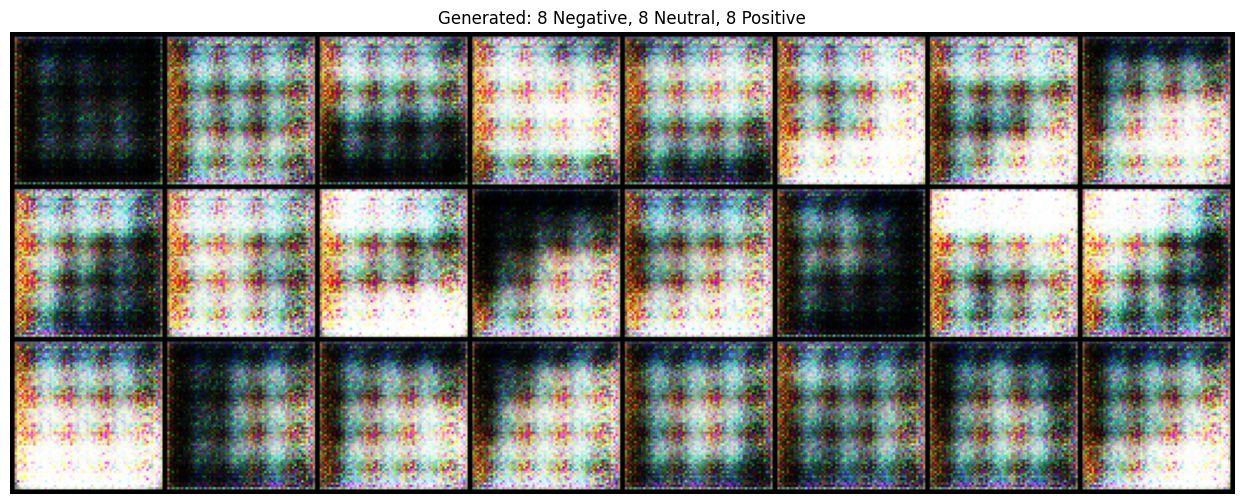

Epoch [11/50] D_loss: 0.0074 G_loss: 7.9546
Epoch [12/50] D_loss: 0.1413 G_loss: 7.2972
Epoch [13/50] D_loss: 0.0115 G_loss: 6.5182
Epoch [14/50] D_loss: 0.1686 G_loss: 7.6286
Epoch [15/50] D_loss: 0.0497 G_loss: 5.4672
Epoch [16/50] D_loss: 0.0740 G_loss: 4.8253


In [ ]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from cgan import CGANGenerator, CGANDiscriminator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nz = 100
nc = 3
ngf, ndf = 64, 64
num_classes = 3  # negative, neutral, positive

generator = CGANGenerator(nz=nz, ngf=ngf, nc=nc, num_classes=num_classes).to(device)
discriminator = CGANDiscriminator(nc=nc, ndf=ndf, num_classes=num_classes).to(device)

criterion = torch.nn.BCELoss()
optimizerG = torch.optim.Adam(generator.parameters(), lr=2e-5, betas=(0.5, 0.999))
optimizerD = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

epochs = 50
plot_interval = 10  # Plot after every 10 epochs

def plot_generated_images(generator, nz, device, num_classes):
    generator.eval()
    with torch.no_grad():
        labels = torch.tensor([0]*8 + [1]*8 + [2]*8, dtype=torch.long, device=device)
        noise = torch.randn(24, nz, 1, 1, device=device)
        fake_images = generator(noise, labels)
        grid = make_grid(fake_images, nrow=8, normalize=True)
        plt.figure(figsize=(18,6))
        plt.axis("off")
        plt.title("Generated: 8 Negative, 8 Neutral, 8 Positive")
        plt.imshow(grid.permute(1,2,0).cpu().numpy())
        plt.show()
    generator.train()

for epoch in range(epochs):
    for real_imgs, labels in dataloader:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)  # 0=neg, 1=neu, 2=pos
        b_size = real_imgs.size(0)
        real_targets = torch.ones(b_size, device=device)
        fake_targets = torch.zeros(b_size, device=device)

        # Train Discriminator
        optimizerD.zero_grad()
        out_real = discriminator(real_imgs, labels)
        loss_real = criterion(out_real, real_targets)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_imgs = generator(noise, labels)
        out_fake = discriminator(fake_imgs.detach(), labels)
        loss_fake = criterion(out_fake, fake_targets)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizerD.step()

        # Train Generator
        optimizerG.zero_grad()
        out_fake = discriminator(fake_imgs, labels)
        g_loss = criterion(out_fake, real_targets)
        g_loss.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

    # Plot after every 'plot_interval' epochs
    if (epoch + 1) % plot_interval == 0:
        print(f'Generating images at epoch {epoch + 1}...')
        plot_generated_images(generator, nz, device, num_classes)